In [1]:
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing
from multiprocessing import Pool
from scipy import interpolate
import scipy.integrate as integrate
from scipy.interpolate import interp1d
import dynesty
import time
from dynesty import plotting as dyplot
from schwimmbad import MPIPool
%matplotlib inline

In [2]:
class Parameter:
    def __init__(self):
        self.c                 = 2.99792458e8 # m/s
        self.G                 = 6.6726e-11 # m^3/(kg*s^2)
        self.MpcInM            = 3.0856e+22 # meter in Mpc
        self.H0                = 67.8 #km/s/Mpc
        self.h                 = self.H0/100
        self.H_0_SI            = self.H0*1000/self.MpcInM
        self.p_c               = 3*(self.H_0_SI*self.c)**2/(8*np.pi*self.G)
        self.pc2m              = 3.0856e+16 # meter in pc
        self.yr2s              = 3.1536e+7 # second in one year
        self.universe_age_yr   = 1.3813e+10 # year
        self.universe_age      = 1.3813e+10*self.yr2s # age of the universe
        self.solar_mass        = 1.989e+30 # solar mass in kg
        self.p_c_SI            = 8.63286552e-27 #kg/m^3
        self.MpcIns            = (self.pc2m*1e6)/self.c

In [3]:
para          = Parameter()

In [4]:
L_TQ       = np.sqrt(3)*1e8 # m
L_LS       = 2.5e9 # m
L_TJ       = 3e9
fc_tq      = para.c/(2*np.pi*L_TQ)
fc_ls      = para.c/(2*np.pi*L_LS)
fc_tj      = para.c/(2*np.pi*L_TJ)

S2O = (3*para.H_0_SI**2)/(2*np.pi**2)

# ORF

In [5]:
t_n     = 3600*3
Df      = 1/t_n

T_tot   = para.yr2s*4

n_T     = int(T_tot/t_n)

freq_0  = np.arange(0,0.05,Df)
freq_sb = freq_0[np.where(freq_0>=1e-5)]

In [6]:
ORF_AA_TQ = np.loadtxt('ORF_AA_TQ.txt')
ORF_TT_TQ = np.loadtxt('ORF_TT_TQ.txt')

In [7]:
ORF_AA_tq = interpolate.interp1d(ORF_AA_TQ[:,0],ORF_AA_TQ[:,1])
ORF_TT_tq = interpolate.interp1d(ORF_TT_TQ[:,0],ORF_TT_TQ[:,1])

In [8]:
ORF_AA_ls = interpolate.interp1d(ORF_AA_TQ[:,0]*(fc_ls/fc_tq),ORF_AA_TQ[:,1])
ORF_TT_ls = interpolate.interp1d(ORF_TT_TQ[:,0]*(fc_ls/fc_tq),ORF_TT_TQ[:,1])
ORF_AA_tj = interpolate.interp1d(ORF_AA_TQ[:,0]*(fc_tj/fc_tq),ORF_AA_TQ[:,1])
ORF_TT_tj = interpolate.interp1d(ORF_TT_TQ[:,0]*(fc_tj/fc_tq),ORF_TT_TQ[:,1])

In [9]:
def orf_aa(f,det):
    if det == 'TQ':
        return ORF_AA_tq(f)
    if det == 'LS':
        return ORF_AA_ls(f)
    if det == 'TJ':
        return ORF_AA_tj(f)
    
def orf_tt(f,det):
    if det == 'TQ':
        return ORF_TT_tq(f)
    if det == 'LS':
        return ORF_TT_ls(f)
    if det == 'TJ':
        return ORF_TT_tj(f)

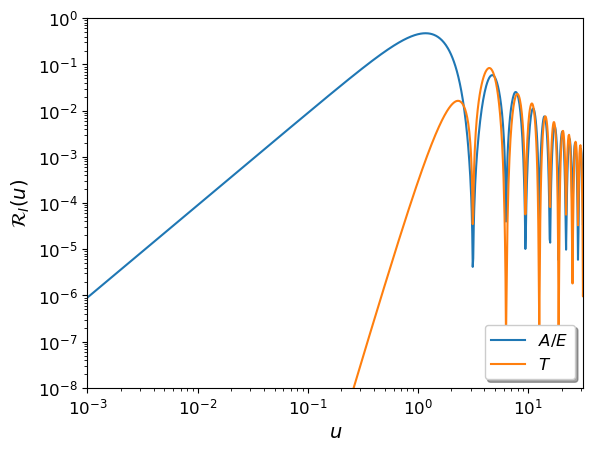

In [10]:
plt.loglog(np.logspace(-3,1.5,1000),orf_aa(np.logspace(-3,1.5,1000)*fc_tq,'TQ'),label=r'$A/E$')
plt.loglog(np.logspace(-3,1.5,1000),orf_tt(np.logspace(-3,1.5,1000)*fc_tq,'TQ'),label=r'$T$')
plt.xlim(10**-3,10**1.5)
plt.ylim(1e-8,1e0)
plt.xlabel(r'$u$',fontsize=14)
plt.ylabel(r'$\mathcal{R}_{I}(u)$',fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12,)
plt.legend(loc='lower right',shadow=True,ncol=1,fontsize=12)
plt.savefig('ORF_AET.pdf',bbox_inches='tight',dpi=500)

$P_{n_{A}}(f)=P_{n_{E}}(f)=\frac{16}{3}\sin\bigg(\frac{f}{f_{\ast}}\bigg)^{2}\bigg(
\bigg[\cos\bigg(\frac{f}{f_{\ast}}\bigg)+2\bigg]P^{p}(f)+2
\bigg[\cos\bigg(\frac{2f}{f_{\ast}}\bigg)+2\cos\bigg(\frac{f}{f_{\ast}}\bigg)+3\bigg]P^{a}(f)\bigg)$

$P_{n_{T}}(f)=\frac{16}{3}\sin\bigg(\frac{f}{f_{\ast}}\bigg)^{2}
\bigg[1-\cos\bigg(\frac{f}{f_{\ast}}\bigg)\bigg]\bigg(P^{p}(f)+2
\bigg[1-\cos\bigg(\frac{f}{f_{\ast}}\bigg)\bigg]P^{a}(f)\bigg)$

$P^{p}(f)=\frac{S_{p}(f)}{(2L)^{2}}$

$P^{a}(f)=\frac{1+(10^{-4}/f)^{2}}{(2\pi f)^{4}}\frac{S_{a}(f)}{(2L)^{2}}$

In [11]:
def Pn_cv(det,chn,theta,f):
    Sp  = 10**theta[0]
    Sa  = 10**theta[1]
    c_a  = (2*np.pi*f)**4
    if (det == 'TQ') | (det == 'TQ2'):
        u_T  = f/fc_tq
        SpTQ = Sp            #m^2/Hz
        SaTQ = Sa*(1+1e-4/f) #m^2/s^4/Hz
        if (chn == 'M'):
            return 1/L_TQ**2*(SpTQ+2*(1+np.cos(u_T)**2)*SaTQ/c_a)
        if (chn == 'A') | (chn == 'E'):
            return 1/L_TQ**2*2*np.sin(u_T)**2*((np.cos(u_T)+2)*SpTQ+2*(np.cos(2*u_T)+2*np.cos(u_T)+3)*SaTQ/c_a)
        if (chn == 'T'):
            return 1/L_TQ**2*8*np.sin(u_T)**2*np.sin(u_T/2)**2*(SpTQ+4*np.sin(u_T/2)**2*SaTQ/c_a)
    if (det == 'LS'):
        u_L  = f/fc_ls
        def Poms(f):
            return Sp*(1+(2e-3/f)**4)
        def Pacc(f):
            return Sa*(1+(0.4e-3/f)**2)*(1+(f/8e-3)**4)
        if (chn == 'M'):
            return 1/L_LS**2*(Poms(f)+2*(1+np.cos(u_L)**2)*Pacc(f)/c_a)
        if (chn == 'A') | (chn == 'E'):
            return 1/L_LS**2*2*np.sin(u_L)**2*((np.cos(u_L)+2)*Poms(f)+2*(np.cos(2*u_L)+2*np.cos(u_L)+3)*Pacc(f)/c_a)
        if (chn == 'T'):
            return 1/L_LS**2*8*np.sin(u_L)**2*np.sin(u_L/2)**2*(Poms(f)+4*np.sin(u_L/2)**2*Pacc(f)/c_a)
    if (det == 'TJ'):
        u_L  = f/fc_tj
        def Poms(f):
            return Sp*(1+(2e-3/f)**4)
        def Pacc(f):
            return Sa*(1+(0.4e-3/f)**2)*(1+(f/8e-3)**4)
        if (chn == 'M'):
            return 1/L_TJ**2*(Poms(f)+2*(1+np.cos(u_L)**2)*Pacc(f)/c_a)
        if (chn == 'A') | (chn == 'E'):
            return 1/L_TJ**2*2*np.sin(u_L)**2*((np.cos(u_L)+2)*Poms(f)+2*(np.cos(2*u_L)+2*np.cos(u_L)+3)*Pacc(f)/c_a)
        if (chn == 'T'):
            return 1/L_TJ**2*8*np.sin(u_L)**2*np.sin(u_L/2)**2*(Poms(f)+4*np.sin(u_L/2)**2*Pacc(f)/c_a)

In [12]:
def Omega_n(chnl,config,f_band):
    f_b      =  f_band[(f_band >= 1e-5) & (f_band <= 1)]
    if (config == 1):
        theta = [-24,-30]
        det = 'TQ'
    if (config == 2):
        theta = [np.log10(2.25e-22),np.log10(9e-30)]
        f_b  =  f_band[(f_band >= 1e-5) & (f_band <= 0.5)]
        det = 'LS'
    if (config == 3):
        theta = [np.log10(6.4e-23),np.log10(9e-30)]
        f_b  =  f_band[(f_band >= 1e-5) & (f_band <= 0.5)]
        det = 'TJ'
    if (chnl == 'A'):
        ORF          = orf_aa(f_b,det)
    if (chnl == 'T'):
        ORF          = orf_tt(f_b,det)
    Omega        = np.zeros((len(ORF),2))
    Omega[:,0]   = f_b
    Omega[:,1]   = 1/S2O*f_b**3*Pn_cv(det,chnl,theta,f_b)/ORF
    return Omega

In [14]:
np.savetxt('Omega_n_TQ.txt',Omega_n('A',1,np.logspace(-4,0,1000)))
np.savetxt('Omega_n_LS.txt',Omega_n('A',2,np.logspace(-5,-1,1000)))

In [15]:
def Omega_pl(chnl,config,f_b,T_tot,rho_th):
    f_ref        = 1e-4
    beta         = np.linspace(-20,20,1000)
    freq         = Omega_n(chnl,config,f_b)[:,0]
    Omega        = Omega_n(chnl,config,f_b)[:,1]
    def Omega_beta_integrate(b):
        return ((freq/f_ref)**b/Omega)**2
    def Omega_beta(b):
        return 1/(T_tot)**0.5*integrate.trapezoid(Omega_beta_integrate(b),freq)**-0.5*(freq/f_ref)**b
    PL           = np.vstack([Omega_beta(b) for b in beta])
    def Omega_pl(x):
        return PL[:,x].max()
    Omega_PL     = np.zeros((len(freq),2))
    Omega_PL[:,0]= freq
    Omega_PL[:,1]= [rho_th*para.h**2*Omega_pl(i) for i in np.arange(0,len(freq),1)]
    return Omega_PL

In [16]:
PL_TQ_T = Omega_pl('T',1,np.logspace(-4,0,200),2*para.yr2s,10)

In [17]:
PL_TQ = Omega_pl('A',1,np.logspace(-4,0,200),2*para.yr2s,10)
PL_LS = Omega_pl('A',2,np.logspace(-5,-0.3,200),4*para.yr2s,10)
PL_TJ = Omega_pl('A',3,np.logspace(-5,-0.3,200),4*para.yr2s,10)

In [31]:
Omega_GW_BBH_FULL_e0      = np.loadtxt('Omega_GW_BBH_circular.txt')
Omega_GW_BBH_FULL_field   = np.loadtxt('Omega_GW_BBH_field.txt')
Omega_GW_BBH_FULL_gc      = np.loadtxt('Omega_GW_BBH_gc.txt')
Omega_GW_BBH_FULL_agn     = np.loadtxt('Omega_GW_BBH_agn.txt')
Omega_GW_BBH_FULL_agn_m2  = np.loadtxt('Omega_GW_BBH_agn_m2.txt')
Omega_GW_BBH_FULL_agn_m12 = np.loadtxt('Omega_GW_BBH_agn_m12.txt')

In [32]:
Omega_GW_BBH_emt_01       = np.loadtxt('Omega_GW_BBH_emt_01.txt')
Omega_GW_BBH_emt_100      = np.loadtxt('Omega_GW_BBH_emt_100.txt')

In [33]:
Omega_GW_bbh_emt_01 = interpolate.interp1d(Omega_GW_BBH_emt_01[:,0], Omega_GW_BBH_emt_01[:,1])
Omega_GW_bbh_emt_100 = interpolate.interp1d(Omega_GW_BBH_emt_100[:,0], Omega_GW_BBH_emt_100[:,1])

In [34]:
Omega_GW_bbh_emt_01(1e-6)

array(3.8690675e-23)

$\Omega_{\rm gw}$

In [35]:
theta_true = [np.log10(6.4e-23),np.log10(9e-30),np.log10(3.98e-16),np.log10(4.79e-7),-5.7,-6.2,np.log10(0.81e-12),-1.67,-2.3]  #Taiji

theta_true = [np.log10(2.25e-22),np.log10(9e-30),np.log10(3.98e-16),np.log10(4.79e-7),-5.7,-6.2,np.log10(0.81e-12),-1.67,-2.3]  #LISA

theta_true = [-24,-30,np.log10(3.98e-16),np.log10(4.79e-7),-5.7,-6.2,np.log10(4e-12),-1.67,-2.3]  #TianQin

In [36]:
R_FIELD  = np.loadtxt('r_FIELD.txt')
R_GC     = np.loadtxt('r_GC.txt')
R_AGN    = np.loadtxt('r_AGN.txt')
R_H1    = np.loadtxt('r_H1.txt')
R_H2    = np.loadtxt('r_H2.txt')
R_H3    = np.loadtxt('r_H3.txt')
R_H4    = np.loadtxt('r_H4.txt')

In [37]:
g_FD  = interpolate.interp1d(R_FIELD[:,0], R_FIELD[:,1])
g_GC  = interpolate.interp1d(R_GC[:,0], R_GC[:,1])
g_AGN = interpolate.interp1d(R_AGN[:,0], R_AGN[:,1])
g_H1 = interpolate.interp1d(R_H1[:,0], R_H1[:,1])
g_H2 = interpolate.interp1d(R_H2[:,0], R_H2[:,1])
g_H3 = interpolate.interp1d(R_H3[:,0], R_H3[:,1])
g_H4 = interpolate.interp1d(R_H4[:,0], R_H4[:,1])

In [38]:
def g_pl(f, f_r,beta):
    return 1 / ((f/f_r)**(beta) + 1)

In [39]:
def Omega_gw_fg(theta,f):
    A1          = 10**theta[2]
    A2          = 10**theta[3]
    alpha1      = theta[4]
    alpha2      = theta[5]
    return A1*(f/fc_tj)**alpha1/(1+A2*(f/fc_tj)**alpha2)

def S_h_gw_fg(theta,f):
    return S2O*Omega_gw_fg(theta,f)/f**3


def Omega_gw_ast0(theta,f):
    f_ref         = 1e-3
    Omega_ast     = 10**theta[6]
    f_r           = 10**theta[7]
    beta          = theta[8]
    return Omega_ast*(f/f_ref)**(2/3)

def S_h_gw_ast0(theta,f):
    return S2O*Omega_gw_ast0(theta,f)/f**3


def Omega_gw_ast(theta,f):
    f_ref         = 1e-3
    Omega_ast     = 10**theta[6]
    f_r           = 10**theta[7]
    beta          = theta[8]
    return Omega_ast*(f/f_ref)**(2/3)*g_pl(f, f_r,beta)

def S_h_gw_ast(theta,f):
    return S2O*Omega_gw_ast(theta,f)/f**3

# In[20]:

def Omega_gw_ast_FD(f):
    Omega_ast     = 10**theta_true[6]
    f_ref         = 1e-3
    return Omega_ast*(f/f_ref)**(2/3)*g_FD(f)

def S_h_gw_ast_FD(f):
    return S2O*Omega_gw_ast_FD(f)/f**3


def Omega_gw_ast_GC(f):
    Omega_ast     = 10**theta_true[6]
    f_ref         = 1e-3
    return Omega_ast*(f/f_ref)**(2/3)*g_GC(f)

def S_h_gw_ast_GC(f):
    return S2O*Omega_gw_ast_GC(f)/f**3


def Omega_gw_ast_AGN(f):
    Omega_ast = 10**theta_true[6]
    f_ref     = 1e-3
    return Omega_ast*(f/f_ref)**(2/3)*g_AGN(f)

def S_h_gw_ast_AGN(f):
    return S2O*Omega_gw_ast_AGN(f)/f**3

def Omega_gw_ast_H1(f):
    Omega_ast = 10**theta_true[6]
    f_ref     = 1e-3
    return Omega_ast*(f/f_ref)**(2/3)*g_H1(f)

def S_h_gw_ast_H1(f):
    return S2O*Omega_gw_ast_H1(f)/f**3

def Omega_gw_ast_H2(f):
    Omega_ast = 10**theta_true[6]
    f_ref     = 1e-3
    return Omega_ast*(f/f_ref)**(2/3)*g_H2(f)

def S_h_gw_ast_H2(f):
    return S2O*Omega_gw_ast_H2(f)/f**3

def Omega_gw_ast_H3(f):
    Omega_ast = 10**theta_true[6]
    f_ref     = 1e-3
    return Omega_ast*(f/f_ref)**(2/3)*g_H3(f)

def S_h_gw_ast_H3(f):
    return S2O*Omega_gw_ast_H3(f)/f**3

def Omega_gw_ast_H4(f):
    Omega_ast = 10**theta_true[6]
    f_ref     = 1e-3
    return Omega_ast*(f/f_ref)**(2/3)*g_H4(f)

def S_h_gw_ast_H4(f):
    return S2O*Omega_gw_ast_H4(f)/f**3

In [40]:
freq_all = np.logspace(-6,2,200)
freq_all0 = np.logspace(-4,-1.5,200)

In [41]:
1.665107429744523621e-16/(1.578702451210823991e-04/1e-4)**(13/3)

2.302189299891344e-17

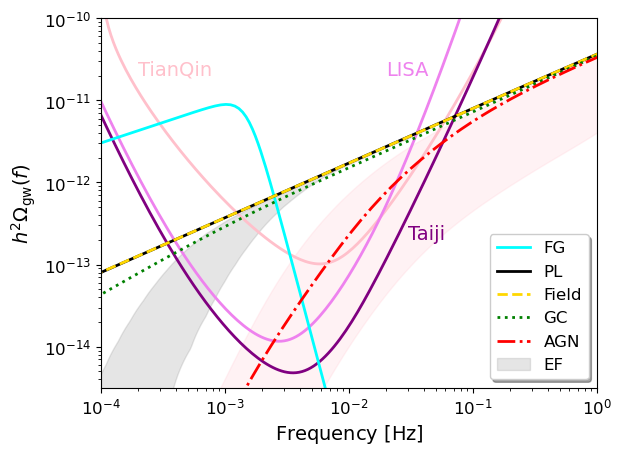

In [43]:
plt.loglog(PL_TQ[:,0],PL_TQ[:,1]/np.sqrt(2)/10,c='pink',linewidth=2)
plt.loglog(PL_LS[:,0],PL_LS[:,1]/np.sqrt(2)/10,c='violet',linewidth=2)
plt.loglog(PL_TJ[:,0],PL_TJ[:,1]/np.sqrt(2)/10,c='purple',linewidth=2)
plt.loglog(freq_sb,para.h**2*Omega_gw_fg(theta_true,freq_sb)/10,c='cyan',label='FG',linewidth=2)
plt.loglog(freq_all,para.h**2*np.array(Omega_GW_BBH_FULL_e0[:,1]),color='black',label='PL',linewidth=2)
plt.loglog(freq_all,para.h**2*np.array(Omega_GW_BBH_FULL_field[:,1]),'--',c='gold',label='Field',linewidth=2)
plt.loglog(freq_all,para.h**2*np.array(Omega_GW_BBH_FULL_gc[:,1]),':',c='green',label='GC',linewidth=2)

plt.loglog(freq_all,para.h**2*np.array(Omega_GW_BBH_FULL_agn[:,1]),'-.',c='red',label='AGN',linewidth=2,alpha=1)




plt.fill_between(freq_all0,para.h**2*Omega_GW_bbh_emt_01(freq_all0),para.h**2*Omega_GW_bbh_emt_100(freq_all0),label='EF',color='grey',alpha=0.2)

plt.fill_between(freq_all,para.h**2*np.array(Omega_GW_BBH_FULL_agn_m2[:,1]),para.h**2*np.array(Omega_GW_BBH_FULL_agn_m12[:,1]),color='pink',alpha=0.2)

plt.text(2e-4, 2e-11, r'TianQin',c='pink',fontsize=14)
plt.text(2e-2, 2e-11, r'LISA',c='violet',fontsize=14)
plt.text(3e-2, 2e-13, r'Taiji',c='purple',fontsize=14)


plt.xlim((1e-4,1e0))
plt.ylim((10**-14.5,10**-10))
plt.xlabel(r'Frequency [$\rm{Hz}$]',fontsize=14)
plt.ylabel(r'$h^{2}\Omega_{\rm gw}(f)$',fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12,)
plt.legend(loc='lower right',shadow=True,ncol=1,fontsize=12)
plt.savefig('BBH_ecc_model.pdf',bbox_inches='tight',dpi=500)

# SNR

In [44]:
def SNR_sgwb(chnl,config,Omega_GW,T):
    Omega_GW0     = Omega_GW[np.where(Omega_GW[:,0]<=0.1)]
    Omega_GW1     = Omega_GW0[np.where(Omega_GW0[:,0]>=1e-4)]
    Omega_GW2     = Omega_GW1[np.where(Omega_GW1[:,1]>0)]
    f_b           = Omega_GW2[:,0]
    Omega_gw      = Omega_GW2[:,1]
    if (config == 1):
        Omega_nI  = Omega_n(chnl,config,f_b)[:,1]
        Omega_nJ  = Omega_nI
        ORF_II    = orf_aa(f_b,'TQ')
        ORF_JJ    = ORF_II
        ORF_IJ    = ORF_II
    if (config == 2):
        Omega_GW0 = Omega_GW2[np.where(Omega_GW2[:,0]<=0.1)]
        f_b       = Omega_GW0[:,0]
        Omega_nI  = Omega_n(chnl,config,f_b)[:,1]
        Omega_nJ  = Omega_nI
        ORF_II    = orf_aa(f_b,'LS')
        ORF_JJ    = ORF_II
        ORF_IJ    = ORF_II
    if (config == 3):
        Omega_GW0 = Omega_GW2[np.where(Omega_GW2[:,0]<=0.1)]
        f_b       = Omega_GW0[:,0]
        Omega_nI  = Omega_n(chnl,config,f_b)[:,1]
        Omega_nJ  = Omega_nI
        ORF_II    = orf_aa(f_b,'TJ')
        ORF_JJ    = ORF_II
        ORF_IJ    = ORF_II
    a             = Omega_gw**2/(Omega_nI*Omega_nJ)
    b             = (Omega_nI+Omega_nJ)/Omega_gw
    c             = ORF_IJ**2/(ORF_II*ORF_JJ)
    W             = 1+(a*(1+b))
    intg          = a*c/W
    return (2*T)**0.5*integrate.trapezoid(intg,f_b)**0.5

In [45]:
SNR_sgwb('A',1,Omega_GW_BBH_FULL_field,2*para.yr2s)

np.float64(12.841264488366903)

In [46]:
SNR_sgwb('A',2,Omega_GW_BBH_FULL_field,4*para.yr2s)

np.float64(64.3171276381385)

In [47]:
SNR_sgwb('A',3,Omega_GW_BBH_FULL_field,4*para.yr2s)

np.float64(171.20097656103252)

In [48]:
SNR_sgwb('A',1,Omega_GW_BBH_FULL_gc,2*para.yr2s)

np.float64(11.207201906803686)

In [49]:
SNR_sgwb('A',2,Omega_GW_BBH_FULL_gc,4*para.yr2s)

np.float64(55.19655094704646)

In [50]:
SNR_sgwb('A',3,Omega_GW_BBH_FULL_gc,4*para.yr2s)

np.float64(149.86436277024836)

In [51]:
SNR_sgwb('A',1,Omega_GW_BBH_FULL_agn,2*para.yr2s)

np.float64(1.6280606700550333)

In [52]:
SNR_sgwb('A',2,Omega_GW_BBH_FULL_agn,4*para.yr2s)

np.float64(3.195545649731558)

In [53]:
SNR_sgwb('A',3,Omega_GW_BBH_FULL_agn,4*para.yr2s)

np.float64(12.650396511265173)

# Gernerate data

In [54]:
def s_ran(det,tp,theta,f):
    if tp == 'FD':
        S_h =  S_h_gw_ast_FD(f) + S_h_gw_fg(theta,f)
    if tp == 'GC':
        S_h =  S_h_gw_ast_GC(f) + S_h_gw_fg(theta,f)
    if tp == 'AGN':
        S_h =  S_h_gw_ast_AGN(f) + S_h_gw_fg(theta,f)
    if tp == 'H1':
        S_h =  S_h_gw_ast_H1(f) + S_h_gw_fg(theta,f)
    if tp == 'H2':
        S_h =  S_h_gw_ast_H2(f) + S_h_gw_fg(theta,f)
    if tp == 'H3':
        S_h =  S_h_gw_ast_H3(f) + S_h_gw_fg(theta,f)
    if tp == 'H4':
        S_h =  S_h_gw_ast_H4(f) + S_h_gw_fg(theta,f)
    mean    =  np.array([0,0,0])
    A1      =  orf_aa(f,det)*S_h + Pn_cv(det,'A',theta,f)    #AA
    A2      =  A1                                            #EE
    A3      =  orf_tt(f,det)*S_h + Pn_cv(det,'T',theta,f)    #TT
    cov     =  np.array([[A1,0,0],[0,A2,0],[0,0,A3]])/2
    temp    =  np.random.multivariate_normal(mean, cov,n_T).T + 1j*np.random.multivariate_normal(mean, cov, n_T).T
    return temp

In [55]:
np.random.seed(9)

S_ran = np.array([s_ran('TJ','AGN',theta_true,f) for f in freq_sb])

In [56]:
S_ran.shape

(539, 3, 11680)

In [57]:
S_ran1 = S_ran[:,0,:]
S_ran2 = S_ran[:,1,:]
S_ran3 = S_ran[:,2,:]

In [58]:
d_AA  = np.sum(abs(S_ran1)**2,axis=1)
d_EE  = np.sum(abs(S_ran2)**2,axis=1)
d_TT  = np.sum(abs(S_ran3)**2,axis=1)

In [59]:
np.save('d_AA_TJ_AGN.npy',d_AA)
np.save('d_EE_TJ_AGN.npy',d_EE)
np.save('d_TT_TJ_AGN.npy',d_TT)

d_AA = np.load('d_AA_TJ_AGN.npy')
d_EE = np.load('d_EE_TJ_AGN.npy')
d_TT = np.load('d_TT_TJ_AGN.npy')

In [60]:
d_AA_EE    = abs(d_AA + d_EE)

In [63]:
import gc
gc.collect()

3776

## Prior distribution

In [64]:
from scipy import stats

# 给定的分位数和对应值
quan6 = [0.05, 0.5, 0.95]
val6 = [np.log10(10**theta_true[6]*14/19), theta_true[6], np.log10(10**theta_true[6]*26/19)]

# 计算高斯分布参数
# 对于正态分布，0.05和0.95分位数对应均值±1.645标准差
mu6 = val6[1]  # 中位数对应均值
sigma6 = (val6[2] - val6[0]) / (2 * 1.645)  # 使用5%和95%分位数计算标准差

def ptform(cube):
    params = np.zeros(len(cube))
    params[0] = 4 * cube[0] + theta_true[0] - 2
    params[1] = 4 * cube[1] + theta_true[1] - 2
    params[2] = 4 * cube[2] + theta_true[2] - 2
    params[3] = 4 * cube[3] + theta_true[3] - 2
    params[4] = 4 * cube[4] + theta_true[4] - 2
    params[5] = 4 * cube[5] + theta_true[5] - 2
    params[6] = stats.norm.ppf(cube[6], loc=mu6, scale=sigma6)
    params[7] = 4 * cube[7] + theta_true[7] - 2
    params[8] = 4 * cube[8] + theta_true[8] - 2
    return params

## Likelihood

In [65]:
Const_Sigma = np.log(8*np.pi**3)
lenf        = len(freq_sb)

In [66]:
def llk(theta):
    f          = freq_sb
    S_h_gw_tot = S_h_gw_fg(theta,f) #+ S_h_gw_ast(theta,f)
    S_tot_AE   = Pn_cv('TJ','A',theta,f) + orf_aa(f,'TJ')*S_h_gw_tot
    S_tot_T    = Pn_cv('TJ','T',theta,f) + orf_tt(f,'TJ')*S_h_gw_tot
    chisq      = abs(d_AA_EE)/S_tot_AE+abs(d_TT)/S_tot_T
    detSigma   = S_tot_AE**2*S_tot_T
    logl       = -0.5 *(sum(chisq + n_T*np.log(detSigma))+n_T*lenf*Const_Sigma)
    if not np.isfinite(logl):
        logl   = -1e100
    return logl

In [67]:
ndim     = len(theta_true)

In [69]:
dns = dynesty.NestedSampler.restore('dyn_ecc_AGN_TJ.save')

In [70]:
res = dns.results

In [71]:
labels = [r'${\rm log}(S_{\rm p})$', r'${\rm log}(S_{\rm a})$',r'$A_{1}$',r'$A_{2}$',r'$\alpha_{1}$',r'$\alpha_{2}$',r'${\rm log}(\Omega_{\rm ast})$',r'$f_{\rm d}$',r'$\beta$']

In [72]:
span0 = [(-22.1942,-22.1934),(-29.054,-29.040),(-15.50,-15.30),(-6.43,-6.22),(-5.82,-5.58),(-6.30,-6.10),(-12.45,-12.33),(-1.55,-1.2),(-2.0,-0.5)]

In [73]:
truths_to_show = theta_true[:7] + [None, None]

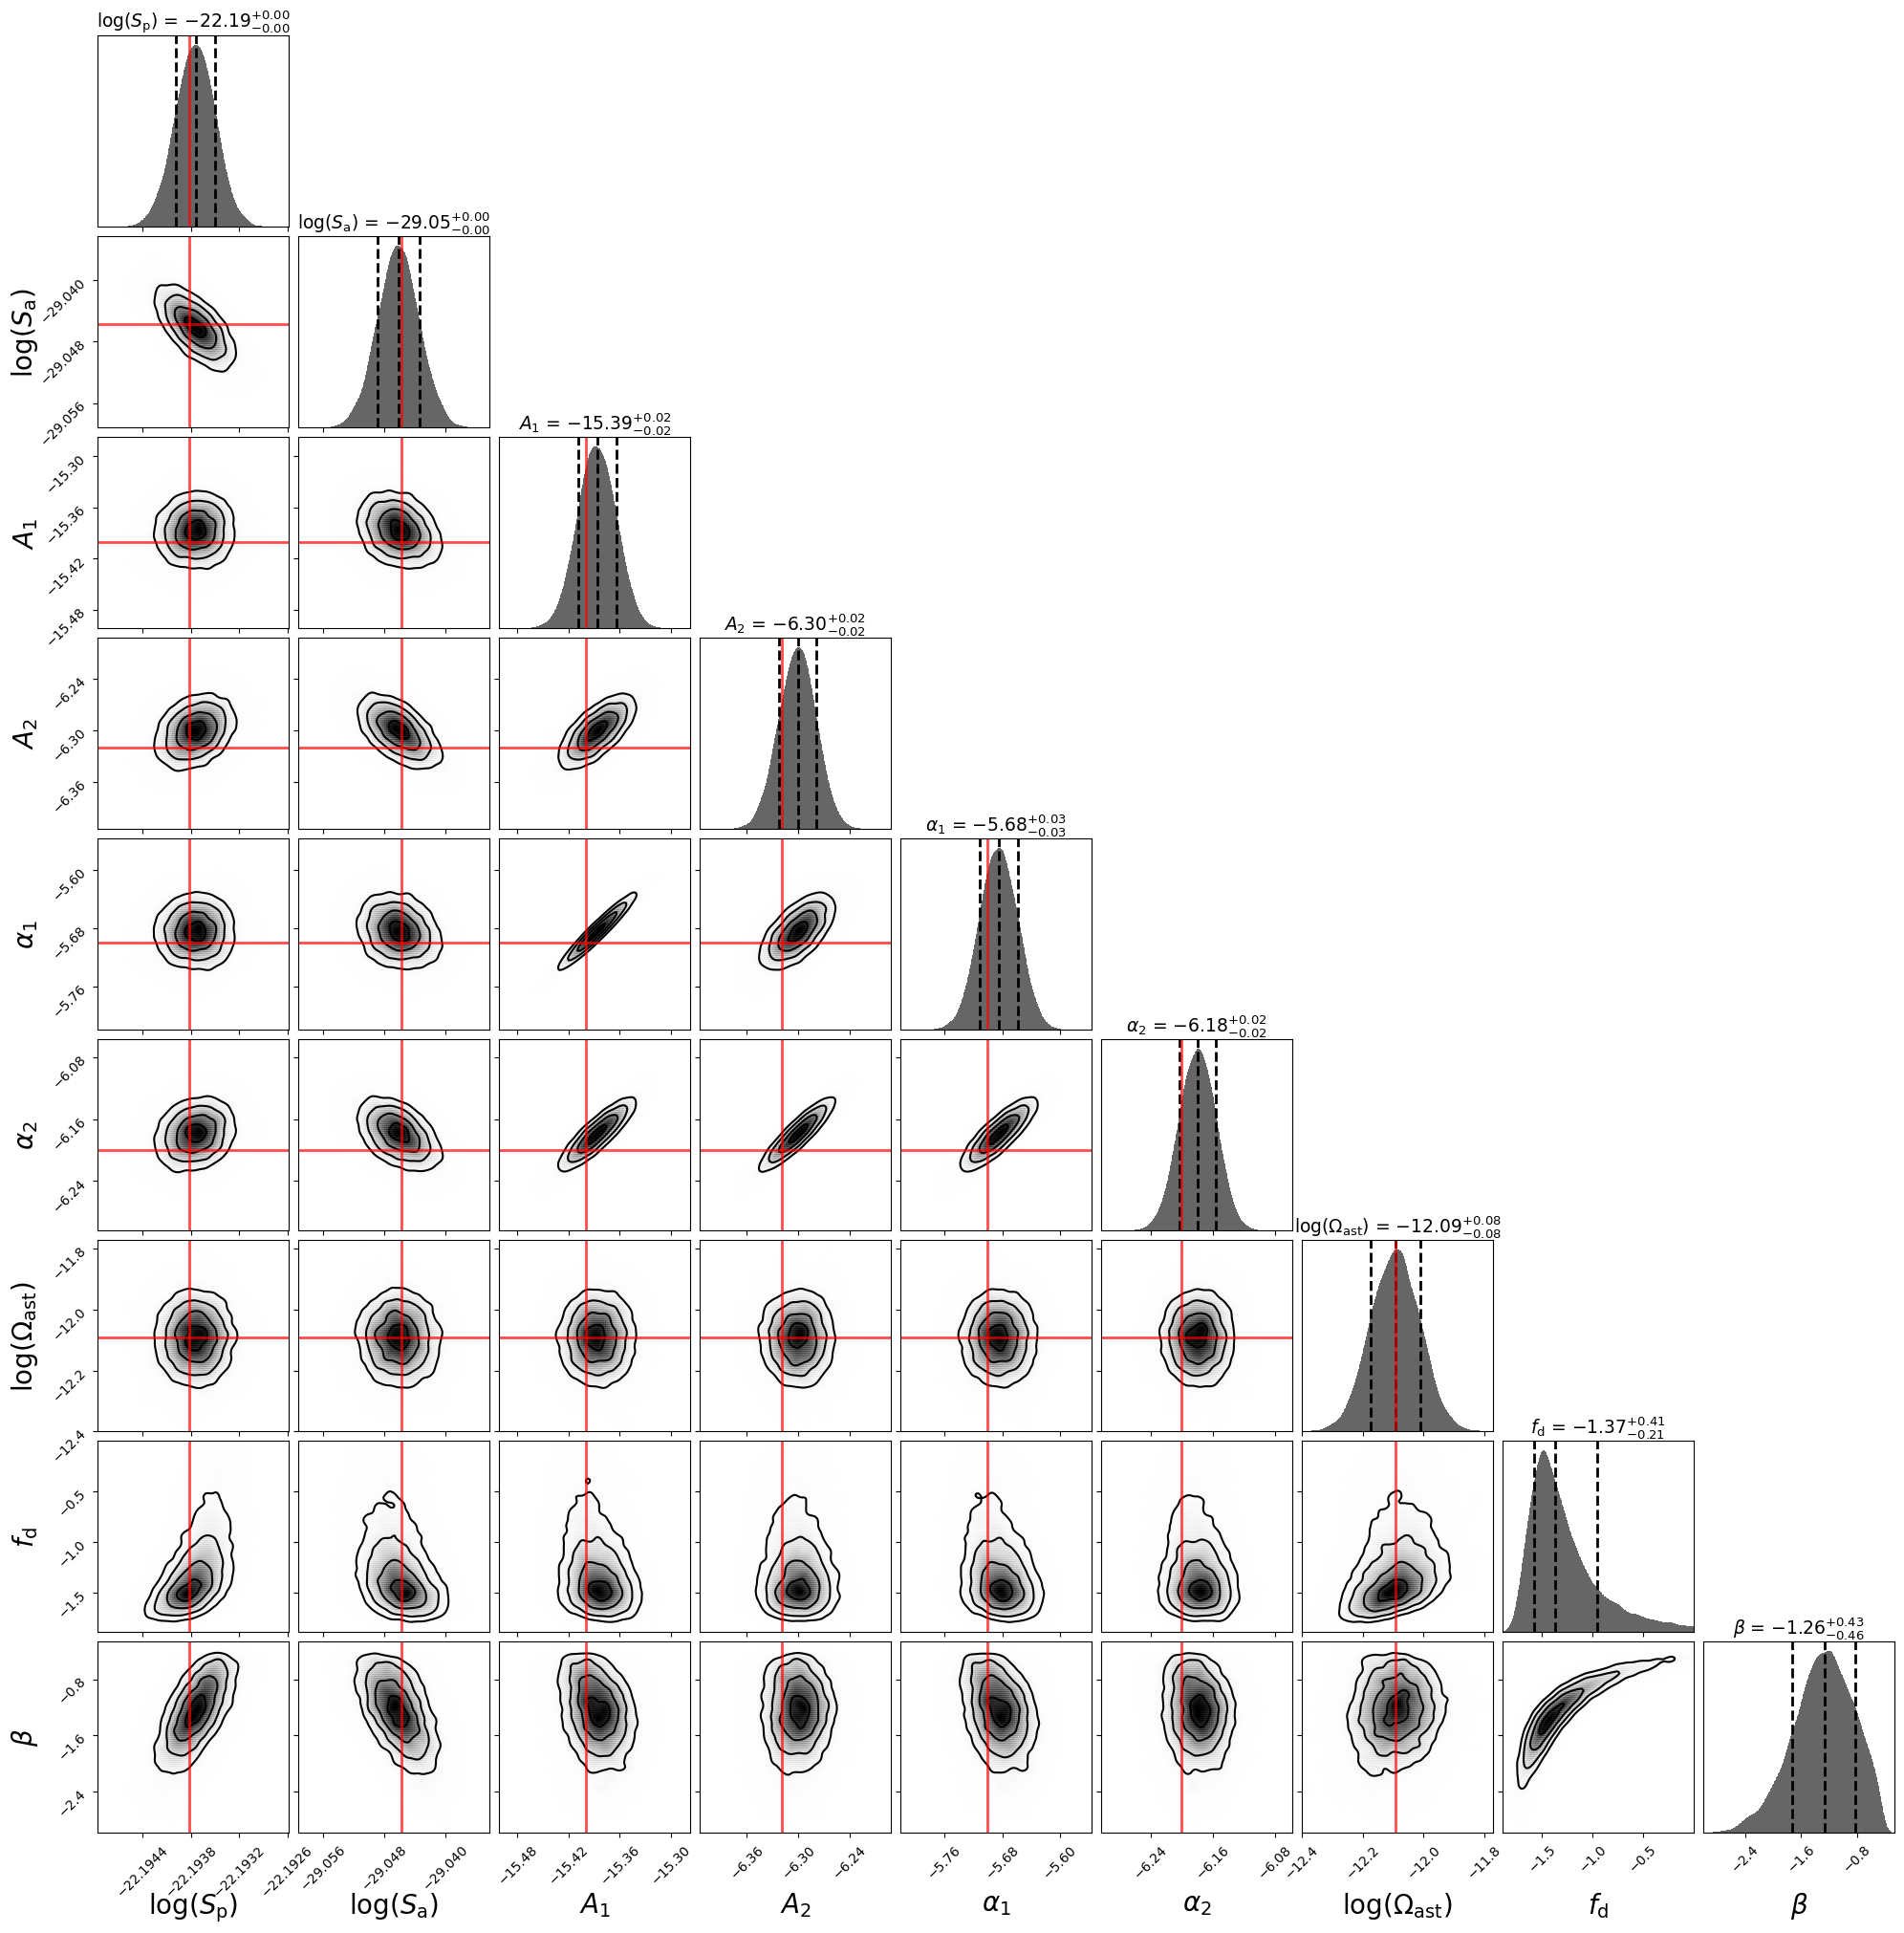

In [77]:
fig, axes = dyplot.cornerplot(res,truths=truths_to_show,truth_color='red',show_titles=True,title_kwargs={'fontsize':13.5},title_quantiles=[0.16, 0.5, 0.84],
                  quantiles=[0.16, 0.5, 0.84],title_fmt='.2f',hist2d_kwargs={'fill_contours':False},label_kwargs={'fontsize':20},labels=labels,max_n_ticks=4)
plt.savefig('SGWB_ecc_AGN_TJ.png',dpi=100)

In [90]:
def g_pl(f, f_r,beta):
    return 1 / ((f/f_r)**(beta) + 1)

In [91]:
freq_sb0  =  np.logspace(-4,2,100)

## Error Bar

In [92]:
import corner

In [93]:
w_sgwb = np.exp(res.logwt-max(res.logwt))

fg_A1 = res.samples[:,2]
fg_A2 = res.samples[:,3]
fg_a1 = res.samples[:,4]
fg_a2 = res.samples[:,5]

Omega_0    =  res.samples[:,6]

f_d        = res.samples[:,7]

Beta       =  res.samples[:,8]

In [94]:
def Omega_fg_DNS(f):
    return 10**fg_A1*(f/fc_tj)**fg_a1/(1+10**fg_A2*(f/fc_tj)**fg_a2)

def Omega_ast_DNS(f):
    f_ref         = 1e-3
    Omega_ast     = 10**Omega_0
    f_r           = 10**f_d
    beta          = Beta
    return Omega_ast*(f/f_ref)**(2/3)*g_pl(f, f_r,beta)

In [95]:
Omega_fg_f_1s = np.array([corner.core.quantile(Omega_fg_DNS(freq_sb0[i]), [0.1587, 0.5, 0.8413], weights=w_sgwb) 
                 for i in range(freq_sb0.shape[0])])

Omega_fg_f_2s = np.array([corner.core.quantile(Omega_fg_DNS(freq_sb0[i]), [0.0238, 0.5, 0.9762], weights=w_sgwb) 
                 for i in range(freq_sb0.shape[0])])

In [96]:
Omega_ast_f_1s = np.array([corner.core.quantile(Omega_ast_DNS(freq_sb0[i]), [0.1587, 0.5, 0.8413], weights=w_sgwb) 
                 for i in range(freq_sb0.shape[0])])

Omega_ast_f_2s = np.array([corner.core.quantile(Omega_ast_DNS(freq_sb0[i]), [0.0238, 0.5, 0.9762], weights=w_sgwb) 
                 for i in range(freq_sb0.shape[0])])

In [97]:
Omega_fg_f_1s_tj = np.loadtxt('Omega_fg_f_1s_tj.txt')
Omega_fg_f_2s_tj = np.loadtxt('Omega_fg_f_2s_tj.txt')
Omega_ast_f_1s_tj = np.loadtxt('Omega_ast_f_1s_tj.txt')
Omega_ast_f_2s_tj = np.loadtxt('Omega_ast_f_2s_tj.txt')

In [98]:
Omega_fg_f_1s_ls = np.loadtxt('Omega_fg_f_1s_ls.txt')
Omega_fg_f_2s_ls = np.loadtxt('Omega_fg_f_2s_ls.txt')
Omega_ast_f_1s_ls = np.loadtxt('Omega_ast_f_1s_ls.txt')
Omega_ast_f_2s_ls = np.loadtxt('Omega_ast_f_2s_ls.txt')

In [99]:
Omega_gw_fg_in  = Omega_gw_fg(theta_true,freq_sb0)
Omega_gw_ast_in = Omega_gw_ast_AGN(freq_sb0)

In [100]:
from matplotlib.lines import Line2D

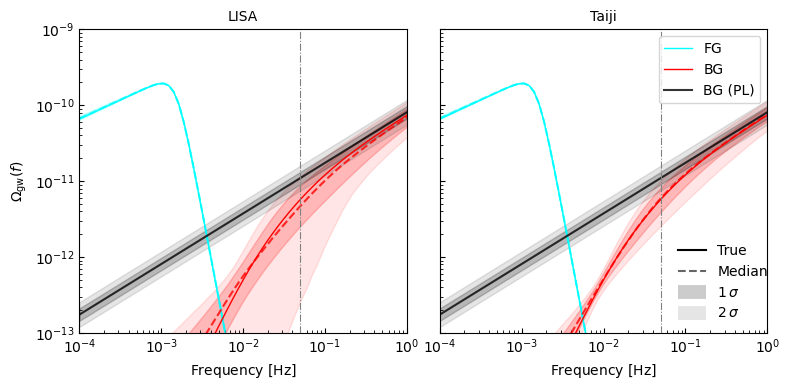

In [101]:
fig = plt.figure(figsize=(8,4))

ax1 = fig.add_subplot(121)

plt.tick_params(which='both',direction='in')

ax1.set_title('LISA',fontsize=10)
ax1.loglog(freq_sb0,Omega_gw_fg_in,color='cyan',linewidth=1)
ax1.loglog(freq_sb0,Omega_fg_f_1s_ls[:,1],'--',color='cyan',alpha=0.8)
ax1.fill_between(freq_sb0,Omega_fg_f_1s_ls[:,0],Omega_fg_f_1s_ls[:,2],color='cyan',alpha=0.2)
ax1.fill_between(freq_sb0,Omega_fg_f_2s_ls[:,0],Omega_fg_f_2s_ls[:,2],color='cyan',alpha=0.1)

ax1.loglog(freq_sb0,Omega_gw_ast_in,color='red',linewidth=1)
ax1.loglog(freq_sb0,Omega_ast_f_1s_ls[:,1],'--',color='red',alpha=0.8)
ax1.fill_between(freq_sb0,Omega_ast_f_1s_ls[:,0],Omega_ast_f_1s_ls[:,2],color='red',alpha=0.2)
ax1.fill_between(freq_sb0,Omega_ast_f_2s_ls[:,0],Omega_ast_f_2s_ls[:,2],color='red',alpha=0.1)

ax1.loglog(freq_sb0,10**mu6*(freq_sb0/0.001)**(2/3),color='black',alpha=0.8)
ax1.fill_between(freq_sb0,10**(mu6 - sigma6)*(freq_sb0/0.001)**(2/3),10**(mu6 + sigma6)*(freq_sb0/0.001)**(2/3),color='black',alpha=0.2)
ax1.fill_between(freq_sb0,10**(mu6 - 2*sigma6)*(freq_sb0/0.001)**(2/3),10**(mu6 + 2*sigma6)*(freq_sb0/0.001)**(2/3),color='black',alpha=0.1)

ax1.axvline(x=0.05,ls='-.',c='grey',linewidth=0.8)

ax1.set_xlim((min(freq_sb0),max(freq_sb0)))
ax1.set_ylim((1e-13,1e-9))
ax1.tick_params(axis='both', which='major', labelsize=10,)
ax1.set_xlabel(r'Frequency [$\rm{Hz}$]',fontsize=10)
ax1.set_ylabel(r'$\Omega_{\rm gw}(f)$',fontsize=10)
ax1.set_xlim((1e-4,1e-0))

plt.tight_layout()


ax2 = fig.add_subplot(122)

plt.tick_params(which='both',direction='in')

ax2.set_title('Taiji',fontsize=10)
ax2.loglog(freq_sb0,Omega_gw_fg_in,color='cyan',label=r'FG',linewidth=1)
ax2.loglog(freq_sb0,Omega_fg_f_1s_tj[:,1],'--',color='cyan',alpha=0.8)
ax2.fill_between(freq_sb0,Omega_fg_f_1s_tj[:,0],Omega_fg_f_1s_tj[:,2],color='cyan',alpha=0.2)
ax2.fill_between(freq_sb0,Omega_fg_f_2s_tj[:,0],Omega_fg_f_2s_tj[:,2],color='cyan',alpha=0.1)

ax2.loglog(freq_sb0,Omega_gw_ast_in,color='red',label=r'BG',linewidth=1)
ax2.loglog(freq_sb0,Omega_ast_f_1s_tj[:,1],'--',color='red',alpha=0.8)
ax2.fill_between(freq_sb0,Omega_ast_f_1s_tj[:,0],Omega_ast_f_1s_tj[:,2],color='red',alpha=0.2)
ax2.fill_between(freq_sb0,Omega_ast_f_2s_tj[:,0],Omega_ast_f_2s_tj[:,2],color='red',alpha=0.1)

ax2.loglog(freq_sb0,10**mu6*(freq_sb0/0.001)**(2/3),color='black',label=r'BG (PL)',alpha=0.8)
ax2.fill_between(freq_sb0,10**(mu6 - sigma6)*(freq_sb0/0.001)**(2/3),10**(mu6 + sigma6)*(freq_sb0/0.001)**(2/3),color='black',alpha=0.2)
ax2.fill_between(freq_sb0,10**(mu6 - 2*sigma6)*(freq_sb0/0.001)**(2/3),10**(mu6 + 2*sigma6)*(freq_sb0/0.001)**(2/3),color='black',alpha=0.1)

ax2.axvline(x=0.05,ls='-.',c='grey',linewidth=0.8)

ax2.set_yticklabels([])
ax2.set_xlim((min(freq_sb0),max(freq_sb0)))
ax2.set_ylim((1e-13,1e-9))
ax2.tick_params(axis='both', which='major', labelsize=10,)
ax2.legend(loc='lower right',ncol=1,fontsize=10)
ax2.set_xlabel(r'Frequency [$\rm{Hz}$]',fontsize=10)
ax2.set_xlim((1e-4,1e-0))

legend1 = ax2.legend(loc='upper right',shadow=False,ncol=1,fontsize=10)
plt.gca().add_artist(legend1)

custom_legend_items  = [
    Line2D([0], [0],linestyle='-',label=r'True',color='black',alpha=1),
    Line2D([0], [0],linestyle='--',label=r'Median',color='black',alpha=0.6),
    Line2D([0], [0],linestyle='--',label=r'$1\,\sigma$',color='black',linewidth=10,alpha=0.2),
    Line2D([0], [0],linestyle='--',label=r'$2\,\sigma$',color='black',linewidth=10,alpha=0.1),
]
legend2 = ax2.legend(handles = custom_legend_items,loc='lower right',bbox_to_anchor=(1.04,0,0,1),frameon=False,fontsize=10)

plt.tight_layout()


plt.subplots_adjust(hspace=0.04)
plt.subplots_adjust(wspace=0.1)

plt.savefig('SGWB_AGN_error.pdf',dpi=500)